In [1]:
!pip uninstall pandas -y
!pip uninstall xarray -y

!pip install pandas==2.2.2
!pip install scikit-learn>=1.5
!pip install xarray==2023.1.0

!pip install evalml

Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
  Using cached pandas-2.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
arviz 0.22.0 requires xarray>=2023.7.0, which is not installed.
evalml 0.84.0 requires pandas<2.1.0,>=1.5.0, but you have pandas 2.2.2 which is incompatible.
cuml-cu12 25.6.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
  Using cached xarray-2023.1.0-py3-none-any.whl.metadata (6.2 kB)
Using cached xarray-2023.1.0-py3-none-any.whl (973 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [2]:
import evalml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
df=pd.read_csv("/content/pizza_v2.csv")

In [4]:
df.shape

(129, 9)

In [5]:
df.isnull().sum()

,0
company,0
price_rupiah,0
diameter,0
topping,0
variant,0
size,0
extra_sauce,0
extra_cheese,0
extra_mushrooms,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          129 non-null    object
 1   price_rupiah     129 non-null    object
 2   diameter         129 non-null    object
 3   topping          129 non-null    object
 4   variant          129 non-null    object
 5   size             129 non-null    object
 6   extra_sauce      129 non-null    object
 7   extra_cheese     129 non-null    object
 8   extra_mushrooms  129 non-null    object
dtypes: object(9)
memory usage: 9.2+ KB


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          129 non-null    object
 1   price_rupiah     129 non-null    object
 2   diameter         129 non-null    object
 3   topping          129 non-null    object
 4   variant          129 non-null    object
 5   size             129 non-null    object
 6   extra_sauce      129 non-null    object
 7   extra_cheese     129 non-null    object
 8   extra_mushrooms  129 non-null    object
dtypes: object(9)
memory usage: 9.2+ KB


In [8]:
df.describe()

,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
count,129,129,129,129,129,129,129,129,129
unique,5,43,12,12,20,6,2,2,2
top,C,"Rp72,000",12 inch,chicken,classic,medium,yes,yes,yes
freq,30,11,49,29,30,41,76,86,72


In [9]:
df.head()

,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,"Rp235,000",22 inch,chicken,double_signature,jumbo,yes,yes,no
1,A,"Rp198,000",20 inch,papperoni,double_signature,jumbo,yes,yes,no
2,A,"Rp120,000",16 inch,mushrooms,double_signature,reguler,yes,yes,yes
3,A,"Rp155,000",14 inch,smoked_beef,double_signature,reguler,yes,no,yes
4,A,"Rp248,000",18 inch,mozzarella,double_signature,jumbo,yes,no,yes


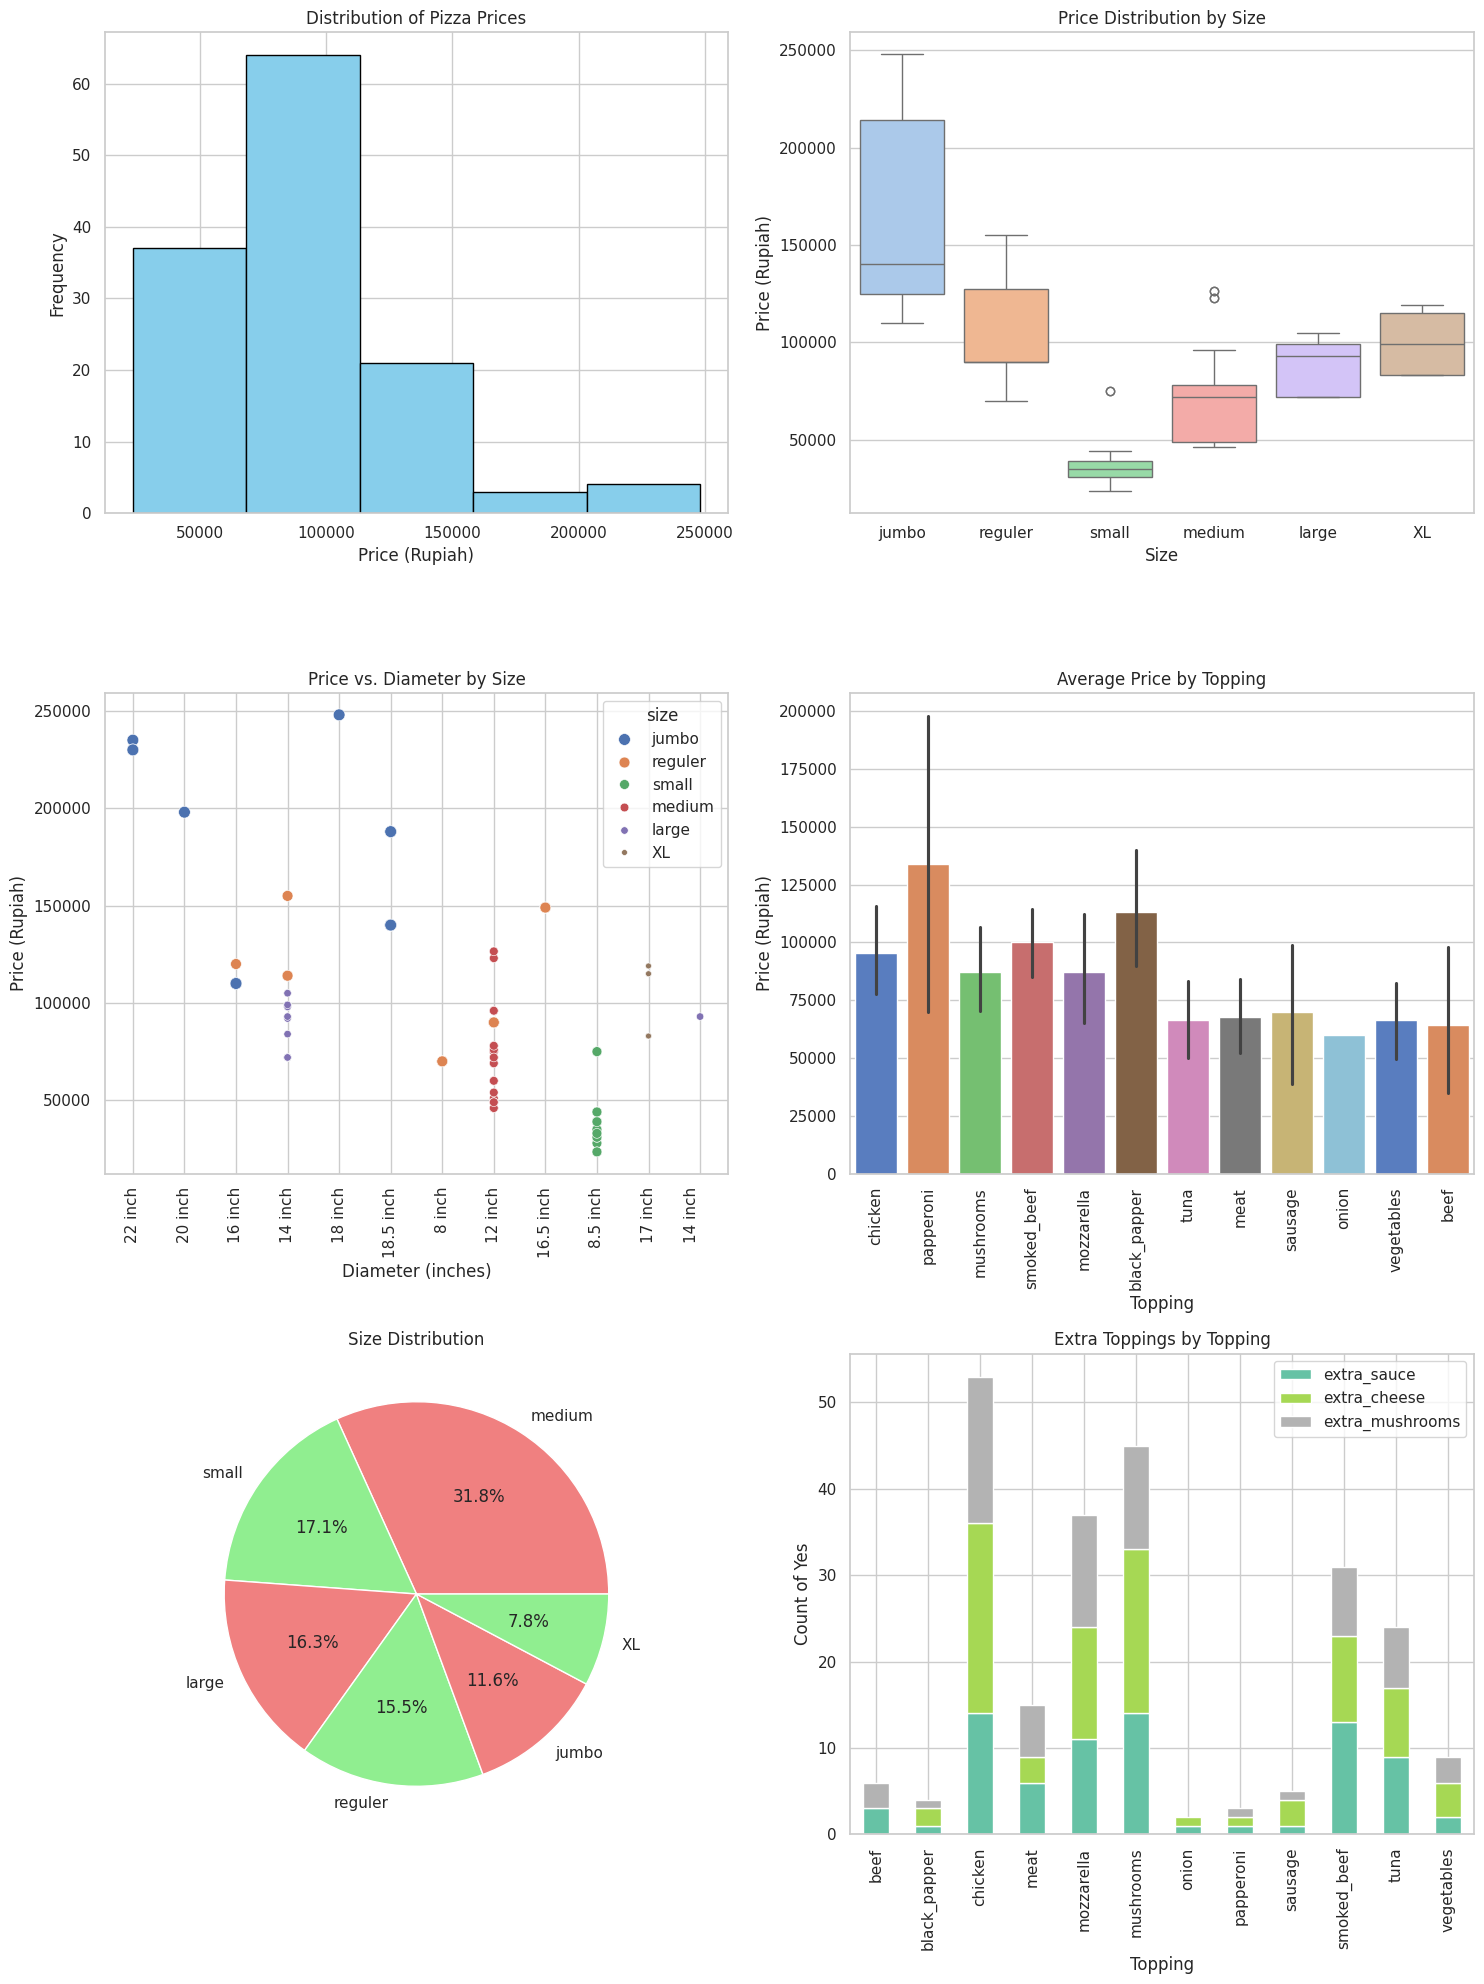

In [10]:
# Clean price_rupiah: remove 'Rp' and commas, convert to numeric
df['price_rupiah'] = df['price_rupiah'].str.replace('Rp', '').str.replace(',', '').astype(float)

# Set up plot style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 20))

# 1. Histogram of Price
plt.subplot(3, 2, 1)
plt.hist(df['price_rupiah'], bins=5, color='skyblue', edgecolor='black')
plt.title('Distribution of Pizza Prices')
plt.xlabel('Price (Rupiah)')
plt.ylabel('Frequency')

# 2. Box Plot of Price by Size
plt.subplot(3, 2, 2)
sns.boxplot(x='size', y='price_rupiah', data=df, palette='pastel')
plt.title('Price Distribution by Size')
plt.xlabel('Size')
plt.ylabel('Price (Rupiah)')

# 3. Scatter Plot of Price vs. Diameter, colored by Size
plt.subplot(3, 2, 3)
sns.scatterplot(x='diameter', y='price_rupiah', hue='size', size='size', data=df, palette='deep')
plt.title('Price vs. Diameter by Size')
plt.xlabel('Diameter (inches)')
plt.ylabel('Price (Rupiah)')
plt.xticks(rotation=90)

# 4. Bar Chart of Price by Topping
plt.subplot(3, 2, 4)
sns.barplot(x='topping', y='price_rupiah', data=df, palette='muted')
plt.title('Average Price by Topping')
plt.xlabel('Topping')
plt.ylabel('Price (Rupiah)')
plt.xticks(rotation=90)

# 5. Pie Chart of Size Distribution
plt.subplot(3, 2, 5)
size_counts = df['size'].value_counts()
plt.pie(size_counts, labels=size_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Size Distribution')

# 6. Stacked Bar Chart of Extra Toppings by Topping
extra_counts = df.groupby('topping')[['extra_sauce', 'extra_cheese', 'extra_mushrooms']].apply(lambda x: (x == 'yes').sum())
extra_counts.plot(kind='bar', stacked=True, colormap='Set2', ax=plt.subplot(3, 2, 6))
plt.title('Extra Toppings by Topping')
plt.xlabel('Topping')
plt.ylabel('Count of Yes')
plt.xticks(rotation=90)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

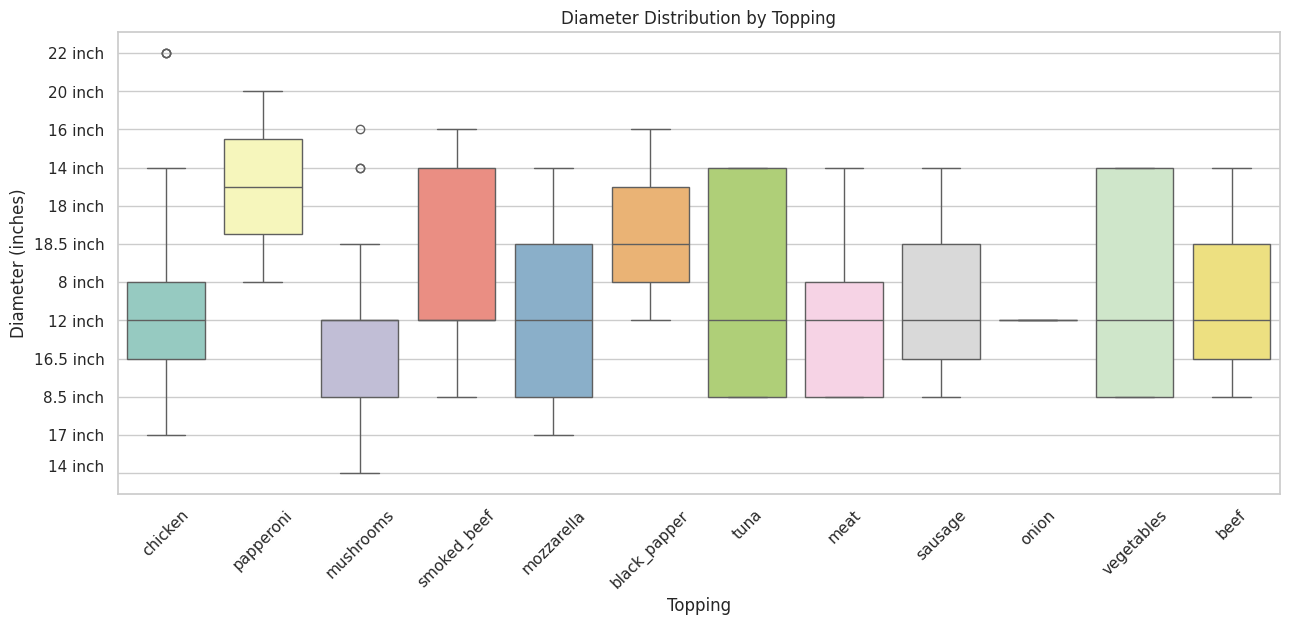

In [11]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='topping', y='diameter', data=df, palette='Set3')
plt.title('Diameter Distribution by Topping')
plt.xlabel('Topping')
plt.ylabel('Diameter (inches)')
plt.xticks(rotation=45)
plt.show()

In [12]:
df['diameter'] = df['diameter'].str.extract('(\d+)').astype(int)

In [13]:
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate

In [14]:
label_mappings = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

In [15]:
for col, mapping in label_mappings.items():
    print(f"\nLabel mapping for '{col}':")
    print(tabulate(mapping.items(), headers=["Original", "Encoded"], tablefmt="grid"))


Label mapping for 'company':
+------------+-----------+
| Original   |   Encoded |
+============+===========+
| A          |         0 |
+------------+-----------+
| B          |         1 |
+------------+-----------+
| C          |         2 |
+------------+-----------+
| D          |         3 |
+------------+-----------+
| E          |         4 |
+------------+-----------+

Label mapping for 'topping':
+--------------+-----------+
| Original     |   Encoded |
+==============+===========+
| beef         |         0 |
+--------------+-----------+
| black_papper |         1 |
+--------------+-----------+
| chicken      |         2 |
+--------------+-----------+
| meat         |         3 |
+--------------+-----------+
| mozzarella   |         4 |
+--------------+-----------+
| mushrooms    |         5 |
+--------------+-----------+
| onion        |         6 |
+--------------+-----------+
| papperoni    |         7 |
+--------------+-----------+
| sausage      |         8 |
+--------

In [16]:
df.rename(columns={"price_rupiah":"price"},inplace=True)

In [17]:
df.head()

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,0,235000.0,22,2,8,1,1,1,0
1,0,198000.0,20,7,8,1,1,1,0
2,0,120000.0,16,5,8,4,1,1,1
3,0,155000.0,14,9,8,4,1,0,1
4,0,248000.0,18,4,8,1,1,0,1


In [18]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("price", axis=1)  # Assuming you want to predict price
y = df["price"]

# Split the data
X_train, X_test, y_train, y_test = evalml.preprocessing.split_data(X, y, test_size=0.2, random_seed=42,problem_type="regression")

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (103, 8) (103,)
Test shape: (26, 8) (26,)


In [19]:
from evalml import AutoMLSearch

In [36]:
automl = AutoMLSearch(
    X_train=X_train,
    y_train=y_train,
    problem_type="regression",
    objective="R2",
    additional_objectives=["MAE", "MSE", "Root Mean Squared Error"],
    allowed_model_families=["linear_model", "xgboost", "random_forest"],
    max_batches=2,
    verbose=True,
    n_jobs=-1,
    ensembling=False
)
automl.search(interactive_plot=False)


AutoMLSearch will use mean CV score to rank pipelines.


INFO:evalml.automl.automl_search.verbose:AutoMLSearch will use mean CV score to rank pipelines.



*****************************


INFO:evalml.automl.automl_search.verbose:
*****************************


* Beginning pipeline search *


...

Best pipeline: XGBoost Regressor w/ Imputer + Select Columns Transformer


INFO:evalml.automl.automl_search.verbose:Best pipeline: XGBoost Regressor w/ Imputer + Select Columns Transformer


Best pipeline R2: 0.775089


INFO:evalml.automl.automl_search.verbose:Best pipeline R2: 0.775089


{1: {'Random Forest Regressor w/ Imputer + RF Regressor Select From Model': 2.0620932579040527,
  'Total time of batch': 2.2461066246032715},
 2: {'XGBoost Regressor w/ Imputer + Select Columns Transformer': 1.3040187358856201,
  'Elastic Net Regressor w/ Imputer + Standard Scaler + Select Columns Transformer': 0.5229809284210205,
  'Total time of batch': 2.211160182952881}}

<Axes: >

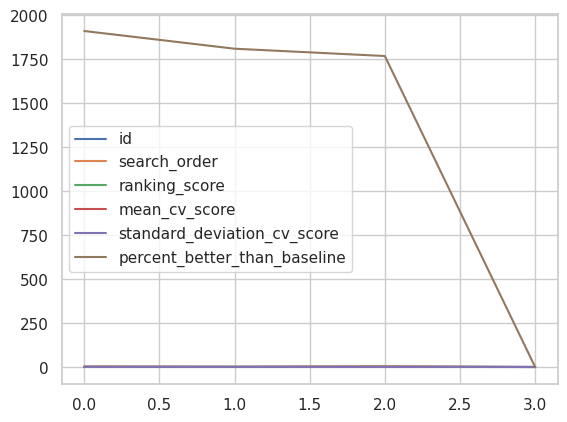

In [37]:
automl.rankings.plot()

In [40]:
automl.rankings

,id,pipeline_name,search_order,ranking_score,mean_cv_score,standard_deviation_cv_score,percent_better_than_baseline,high_variance_cv,parameters
0,2,XGBoost Regressor w/ Imputer + Select Columns ...,2,0.775089,0.775089,0.048110,1911.728424,False,{'Imputer': {'categorical_impute_strategy': 'm...
1,1,Random Forest Regressor w/ Imputer + RF Regres...,1,0.731998,0.731998,0.054957,1811.005840,False,{'Imputer': {'categorical_impute_strategy': 'm...
2,3,Elastic Net Regressor w/ Imputer + Standard Sc...,3,0.714184,0.714184,0.112447,1769.366125,False,{'Imputer': {'categorical_impute_strategy': 'm...
3,0,Mean Baseline Regression Pipeline,0,-0.042782,-0.042782,0.027179,0.000000,False,{'Baseline Regressor': {'strategy': 'mean'}}


In [42]:
best_pipeline=automl.best_pipeline
best_pipeline

pipeline = RegressionPipeline(component_graph={'Imputer': ['Imputer', 'X', 'y'], 'Select Columns Transformer': ['Select Columns Transformer', 'Imputer.x', 'y'], 'XGBoost Regressor': ['XGBoost Regressor', 'Select Columns Transformer.x', 'y']}, parameters={'Imputer':{'categorical_impute_strategy': 'most_frequent', 'numeric_impute_strategy': 'mean', 'boolean_impute_strategy': 'most_frequent', 'categorical_fill_value': None, 'numeric_fill_value': None, 'boolean_fill_value': None}, 'Select Columns Transformer':{'columns': ['diameter', 'topping', 'variant', 'size']}, 'XGBoost Regressor':{'eta': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 100, 'n_jobs': -1}}, random_seed=0)

In [43]:
automl.describe_pipeline(automl.rankings.iloc[0]["id"])


*************************************************************


INFO:evalml.pipelines.pipeline_base.describe:
*************************************************************


* XGBoost Regressor w/ Imputer + Select Columns Transformer *


INFO:evalml.pipelines.pipeline_base.describe:* XGBoost Regressor w/ Imputer + Select Columns Transformer *


*************************************************************


...

INFO:evalml.automl.automl_search.describe_pipeline:Cross Validation


----------------


INFO:evalml.automl.automl_search.describe_pipeline:----------------


               R2       MAE           MSE  Root Mean Squared Error # Training # Validation
0           0.739 14009.505 655018868.804                25593.336         68           35
1           0.830 11014.999 285932958.064                16909.552         69           34
2           0.756  8633.320 245545571.119                15669.894         69           34
mean        0.775 11219.275 395499132.662                19390.927          -            -
std         0.048  2693.908 225656055.406                 5407.088          -            -
coef of var 0.062     0.240         0.571                    0.279          -            -


INFO:evalml.automl.automl_search.describe_pipeline:               R2       MAE           MSE  Root Mean Squared Error # Training # Validation
0           0.739 14009.505 655018868.804                25593.336         68           35
1           0.830 11014.999 285932958.064                16909.552         69           34
2           0.756  8633.320 245545571.119                15669.894         69           34
mean        0.775 11219.275 395499132.662                19390.927          -            -
std         0.048  2693.908 225656055.406                 5407.088          -            -
coef of var 0.062     0.240         0.571                    0.279          -            -


In [44]:
best_pipeline.score(X_test, y_test, objectives=["R2"])

OrderedDict([('R2', 0.8992569223458418)])

In [45]:
best_pipeline.save("best_pipeline.pkl")
model=automl.load("best_pipeline.pkl")

In [47]:
y_pred=model.predict(X_test)
residuals = y_test - y_pred

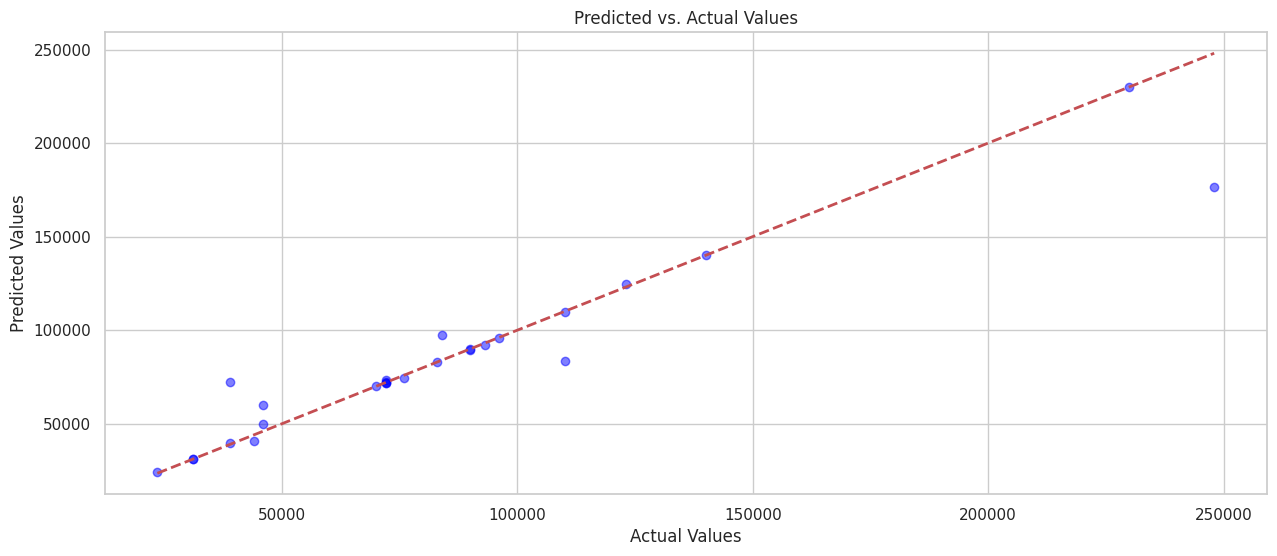

In [48]:
plt.figure(figsize=(15, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values')
plt.show()

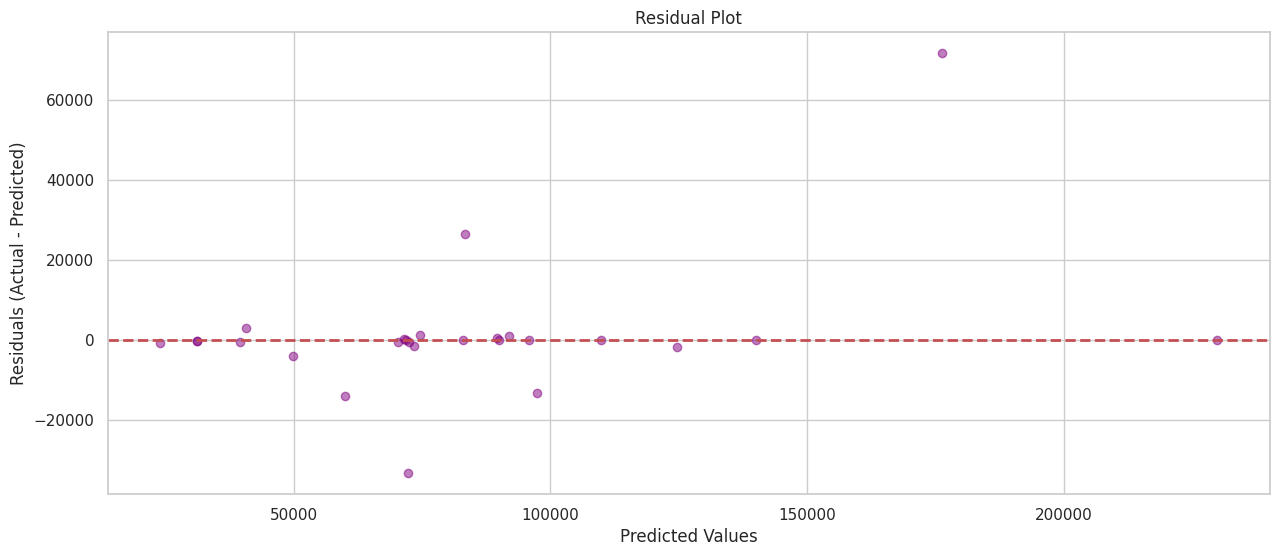

In [49]:
plt.figure(figsize=(15, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

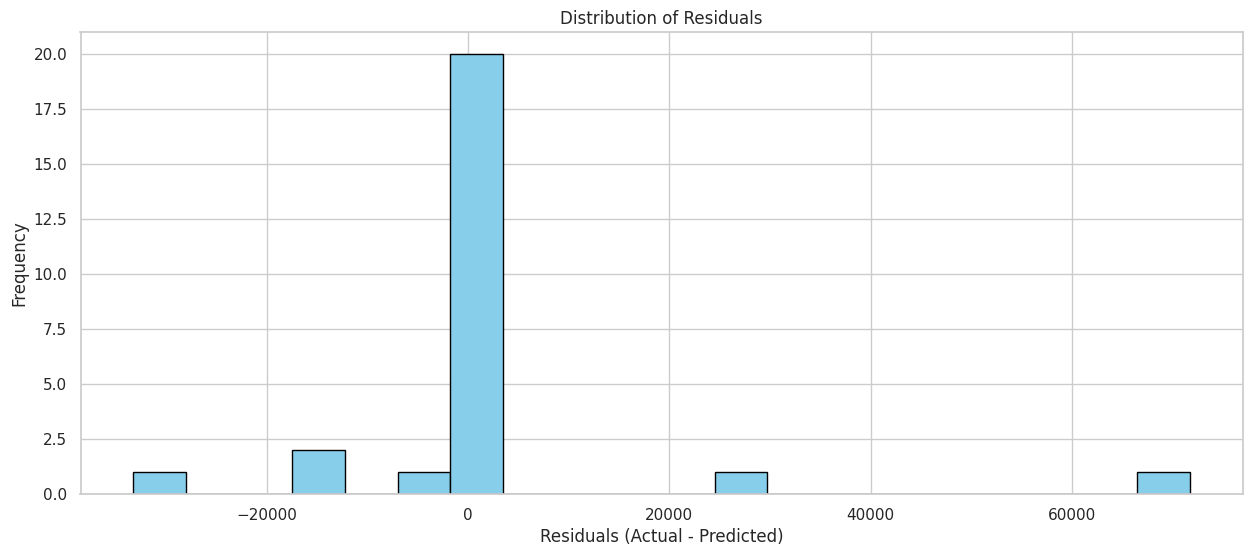

In [50]:
plt.figure(figsize=(15, 6))
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

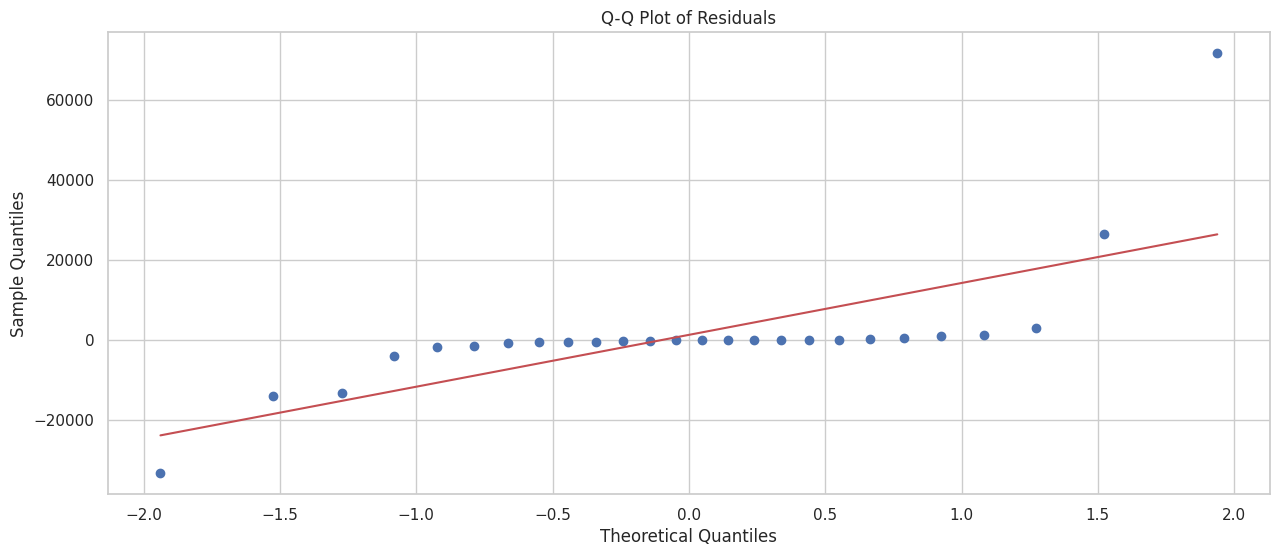

In [52]:
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
plt.figure(figsize=(15, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

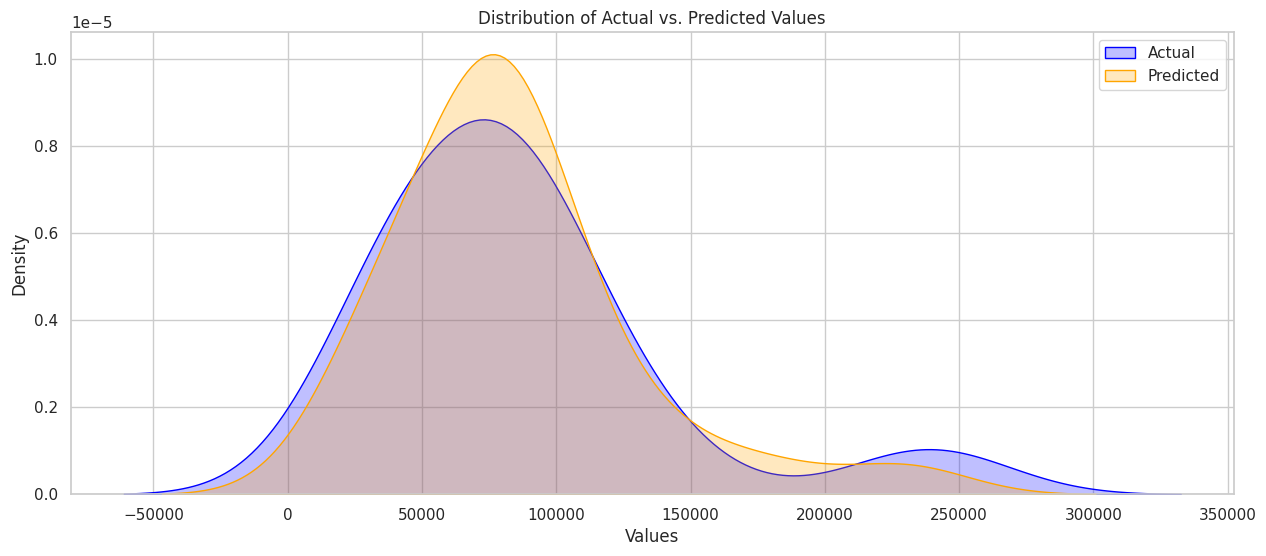

In [53]:
plt.figure(figsize=(15, 6))
sns.kdeplot(y_test, label='Actual', color='blue', fill=True)
sns.kdeplot(y_pred, label='Predicted', color='orange', fill=True)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Distribution of Actual vs. Predicted Values')
plt.legend()
plt.show()

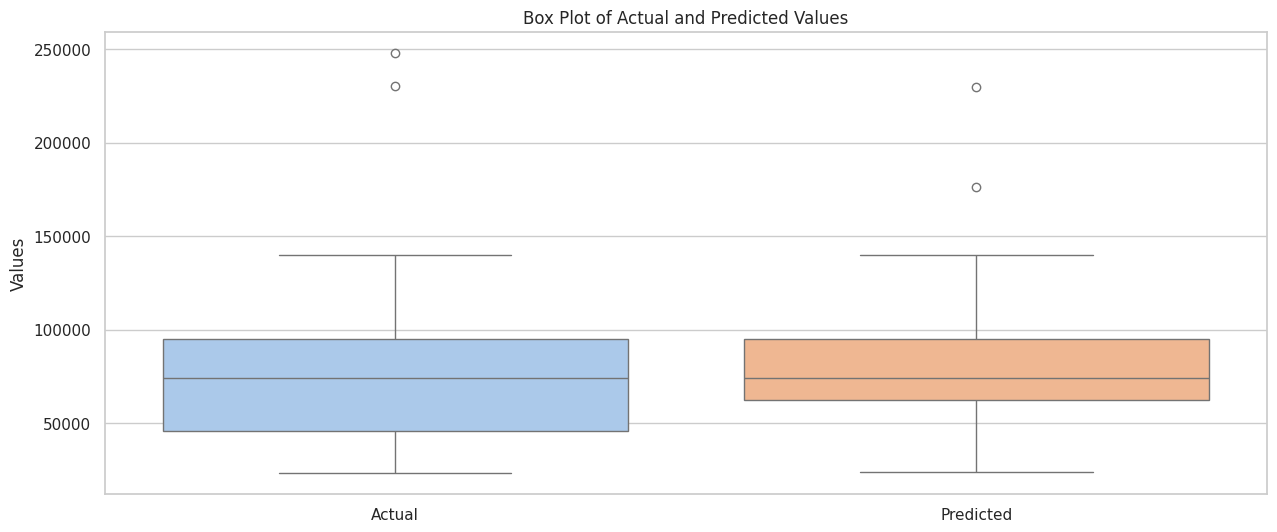

In [54]:
plt.figure(figsize=(15, 6))
data = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
sns.boxplot(data=data, palette='pastel')
plt.title('Box Plot of Actual and Predicted Values')
plt.ylabel('Values')
plt.show()

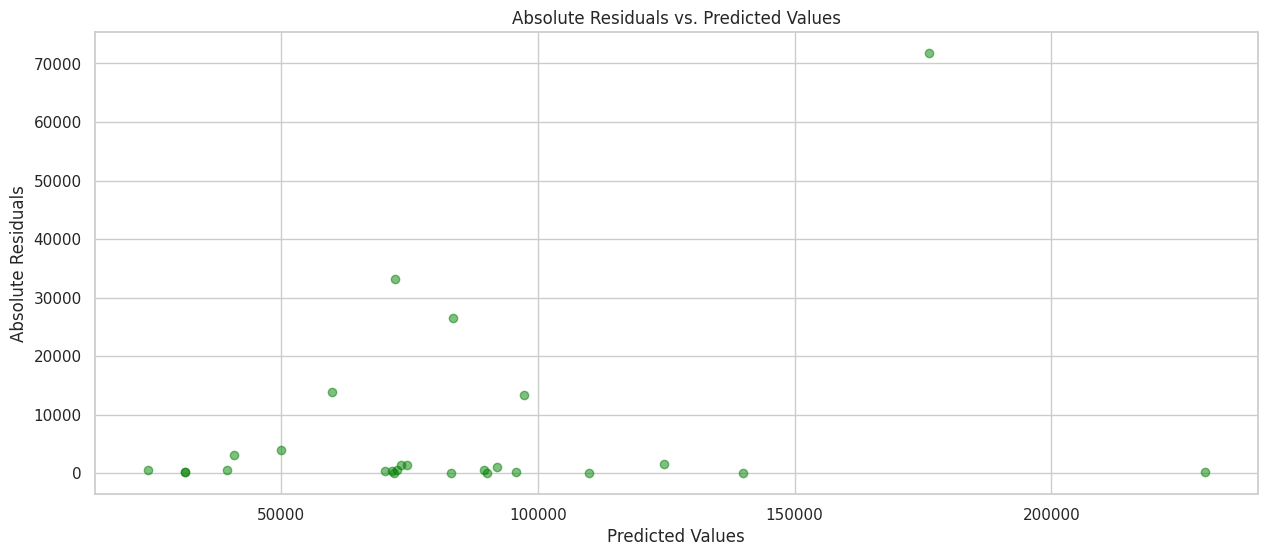

In [55]:
plt.figure(figsize=(15, 6))
plt.scatter(y_pred, np.abs(residuals), color='green', alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Absolute Residuals')
plt.title('Absolute Residuals vs. Predicted Values')
plt.show()

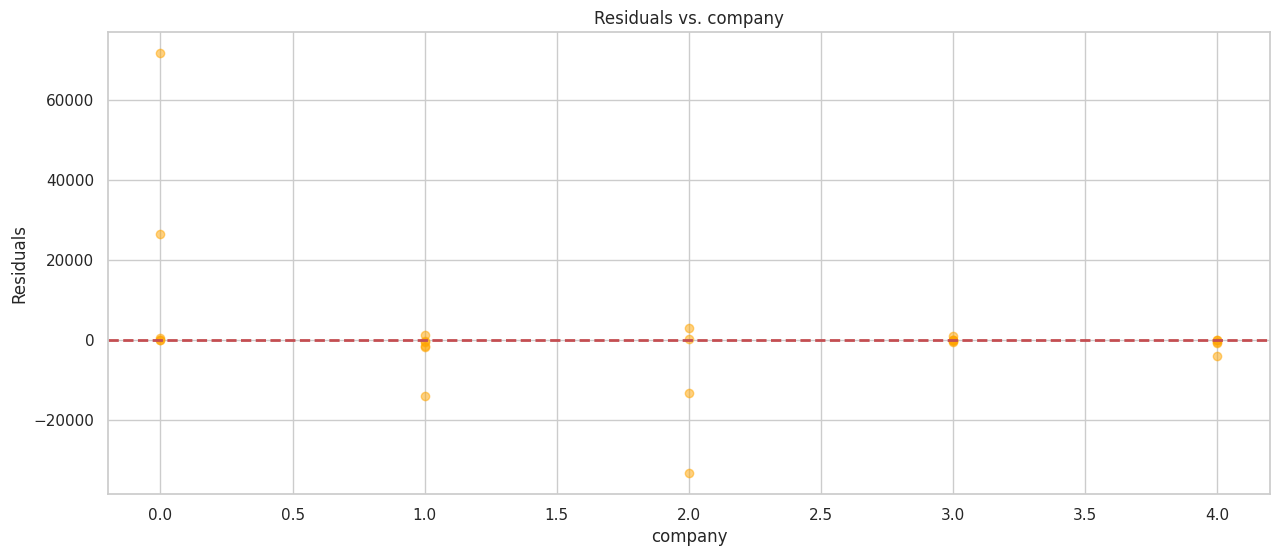

In [56]:
# Requires X_test to be defined
plt.figure(figsize=(15, 6))
if isinstance(X_test, pd.DataFrame):
    feature = X_test.iloc[:, 0]  # First feature (e.g., diameter)
    feature_name = X_test.columns[0]
else:
    feature = X_test[:, 0]  # First feature if X_test is numpy array
    feature_name = 'Feature 0'
plt.scatter(feature, residuals, color='orange', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel(feature_name)
plt.ylabel('Residuals')
plt.title(f'Residuals vs. {feature_name}')
plt.show()

In [58]:
! pip freeze

absl-py==1.4.0
accelerate==1.10.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.10.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.7.2
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.8.11.0.41.9
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.15.0
bigquery-magics==0.10.2
black==25.1.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.7.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
catboost==1.2.8
category-encoders==2.5.1.post0
certifi==2025.8.3
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.3
chex==0.1.90
cho